Generated plot_A.png
Generated plot_B1.png
Generated plot_B2.png


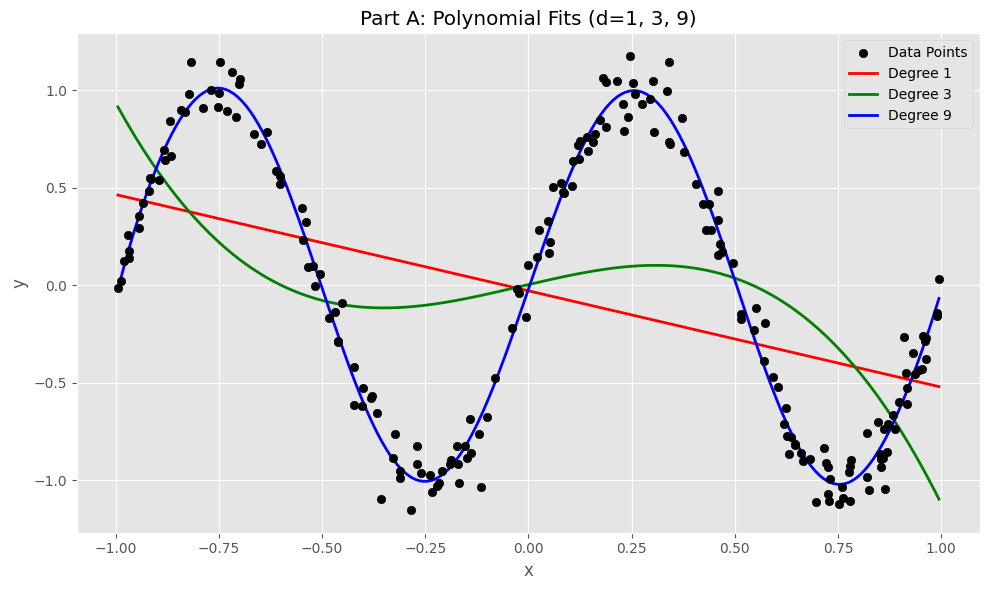

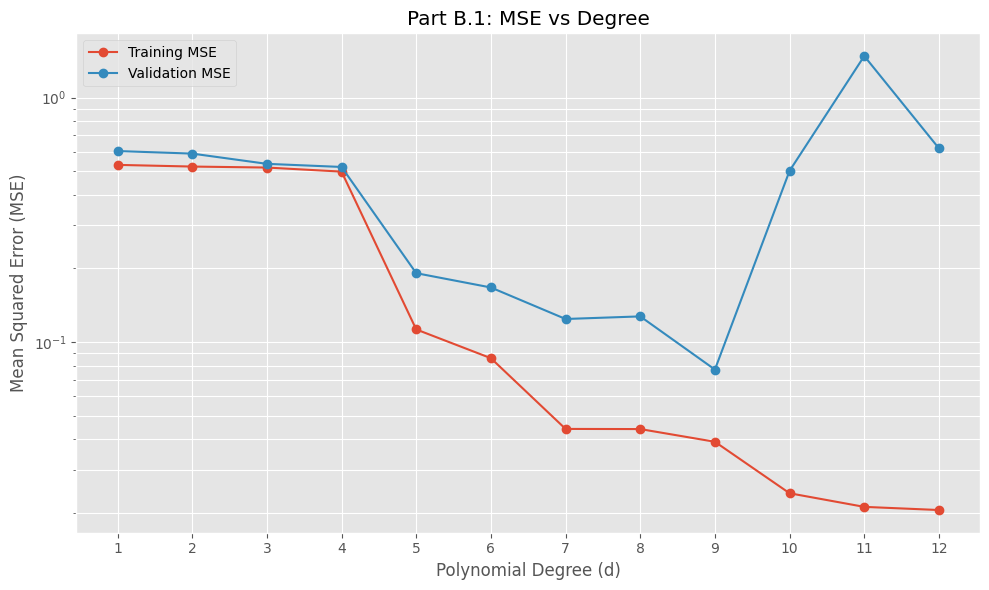

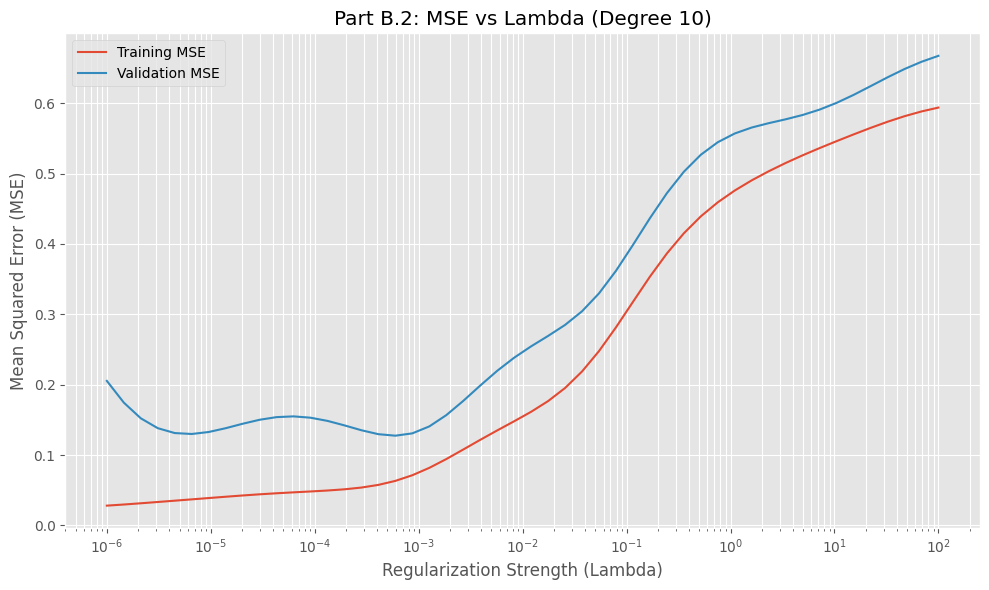

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

def get_poly_features(x, degree):
    """
    Generates polynomial features [1, x, x^2, ..., x^d]
    """
    X = np.ones((len(x), 1))
    for d in range(1, degree + 1):
        X = np.hstack((X, x[:, None]**d))
    return X

def fit_ridge(X, y, lambd=0):
    """
    Solves Ridge Regression using the closed-form Normal Equation:
    theta = (X.T * X + lambda * I)^-1 * X.T * y
    """
    n_feat = X.shape[1]
    I = np.eye(n_feat)
    I[0, 0] = 0  # Do not regularize the bias term
    return np.linalg.solve(X.T @ X + lambd * I, X.T @ y)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Load Data
try:
    df_A = pd.read_csv('data_A.csv')
    df_B_train = pd.read_csv('data_B_train.csv')
    df_B_val = pd.read_csv('data_B_val.csv')
except FileNotFoundError:
    print("Error: CSV files not found. Please ensure data_A.csv, data_B_train.csv, and data_B_val.csv are present.")
    exit()

# Part A: Polynomial Fits on Dataset A
x_A = df_A['x'].values
y_A = df_A['y'].values
x_grid = np.linspace(x_A.min(), x_A.max(), 200)

plt.figure(figsize=(10, 6))
plt.scatter(x_A, y_A, color='black', label='Data Points', zorder=5)

for d, color in zip([1, 3, 9], ['red', 'green', 'blue']):
    # Train
    X_train = get_poly_features(x_A, d)
    theta = fit_ridge(X_train, y_A, lambd=0)

    # Predict for plotting
    X_grid_poly = get_poly_features(x_grid, d)
    y_grid = X_grid_poly @ theta

    plt.plot(x_grid, y_grid, color=color, linewidth=2, label=f'Degree {d}')

plt.title('Part A: Polynomial Fits (d=1, 3, 9)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.savefig('plot_A.png')
print("Generated plot_A.png")

# Part B.1: Effect of Polynomial Degree
x_tr = df_B_train['x'].values
y_tr = df_B_train['y'].values
x_val = df_B_val['x'].values
y_val = df_B_val['y'].values

degrees = range(1, 13)
train_err = []
val_err = []

for d in degrees:
    X_tr_poly = get_poly_features(x_tr, d)
    X_val_poly = get_poly_features(x_val, d)

    theta = fit_ridge(X_tr_poly, y_tr, lambd=0)

    train_err.append(mse(y_tr, X_tr_poly @ theta))
    val_err.append(mse(y_val, X_val_poly @ theta))

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_err, 'o-', label='Training MSE')
plt.plot(degrees, val_err, 'o-', label='Validation MSE')
plt.xlabel('Polynomial Degree (d)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Part B.1: MSE vs Degree')
plt.legend()
plt.yscale('log')
plt.xticks(degrees)
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.savefig('plot_B1.png')
print("Generated plot_B1.png")


# Part B.2: Effect of Ridge Regularization
# We choose a high degree (d=10) to demonstrate the effect of regularization on overfitting.
fixed_d = 10
lambdas = np.logspace(-6, 2, 50)
tr_err_ridge = []
val_err_ridge = []

X_tr_fixed = get_poly_features(x_tr, fixed_d)
X_val_fixed = get_poly_features(x_val, fixed_d)

for l in lambdas:
    theta = fit_ridge(X_tr_fixed, y_tr, lambd=l)

    tr_err_ridge.append(mse(y_tr, X_tr_fixed @ theta))
    val_err_ridge.append(mse(y_val, X_val_fixed @ theta))

plt.figure(figsize=(10, 6))
plt.plot(lambdas, tr_err_ridge, label='Training MSE')
plt.plot(lambdas, val_err_ridge, label='Validation MSE')
plt.xscale('log')
plt.xlabel('Regularization Strength (Lambda)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'Part B.2: MSE vs Lambda (Degree {fixed_d})')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.savefig('plot_B2.png')
print("Generated plot_B2.png")